# Logistic Regression

Logistic regression is a supervised machine learning algorithm that is used for classification tasks. In classification tasks, the dependent variable (target) is categorical (i.e. has discrete classes). Logistic regression builds a model that estimates the probability of a class occurring based on some independent variables.

## The Equation

The hypothesis function of logistic regression, which predicts the probability that an observation in the data belongs to a certain class, needs to be a function that produces values between 0 and 1. Thus, the sigmoid function can be used:
$$h_\theta(x) = g(\theta^T x) = \frac{1}{1 + e^{-\theta^T x}}$$

$$\theta^T x$$ is just a shorthand for the linear regression hypothesis
- θ = array of all your thetas → [θ_0, θ_1, θ_2, ...]
- x = array of all your features → [x_0, x_1, x_2, ...]
- θᵀx = multiply each theta by its feature and sum them all up

So in Logistic Regression:
$$g(\theta^T x) = \frac{1}{1 + e^{-\theta^T x}}$$
We're just feeding the same linear equation from Linear Regression into the sigmoid function to squish the output between 0 and 1.

In binary logistic regression, the target has only two possible outcomes (e.g. 0 or 1). In this case, to perform classification, an estimated probability that is less than 0.5 will predict class 0 while an estimated probability greater than 0.5 will predict class 1.

In [5]:
import pandas
import numpy as np
import matplotlib.pyplot as plot
from sklearn import linear_model
from sklearn.model_selection import train_test_split

            exam1       exam2    decision
count  100.000000  100.000000  100.000000
mean    65.644274   66.221998    0.600000
std     19.458222   18.582783    0.492366
min     30.058822   30.603263    0.000000
25%     50.919511   48.179205    0.000000
50%     67.032988   67.682381    1.000000
75%     80.212529   79.360605    1.000000
max     99.827858   98.869436    1.000000


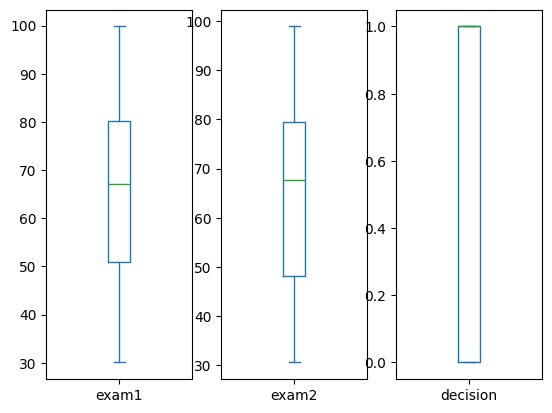

In [6]:
data = pandas.read_csv('acceptance_data.txt', names = ['exam1','exam2','decision'])

# Step 1
print(data.describe())
data.plot(kind='box', subplots=True)
plot.show()

<class 'pandas.DataFrame'>


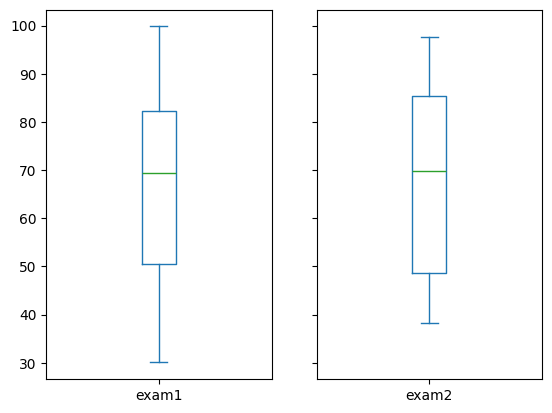

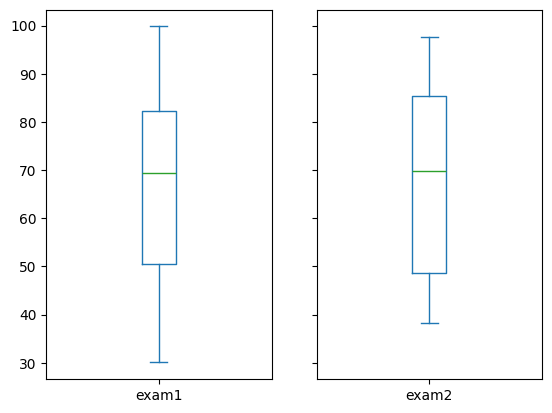

In [7]:
# Steps 2 and 3
X = data.drop(columns=['decision']).round(2)
y = data['decision']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=100)

print(type(X_train))
X_train.plot(kind='box', subplots=True, sharey=True)
plot.show()

# Task 1: Perform feature scaling

X_train.plot(kind='box', subplots=True, sharey=True)
plot.show()

X_train = X_train.to_numpy().reshape((-1,2))
X_test = X_test.to_numpy().reshape((-1,2))
y_train = y_train.to_numpy() # What if the decision was "Yes" and "No"?
y_test = y_test.to_numpy()

xmin = X_train.min(axis=0)
xmax = X_train.max(axis=0)

# 2. Apply the Min-Max formula to scale the data between 0 and 1
X_train = (X_train - xmin) / (xmax - xmin)
X_test = (X_test - xmin) / (xmax - xmin)

In [8]:
# Step 4
model = linear_model.LogisticRegression(solver='sag') #Activity:What is the purpose of solver parameter, what does 'sag' stand for, and briefly describe two other solver options available
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [9]:
print('Coefficients: \n', model.coef_, " ", model.intercept_)

# Step 5
y_pred = model.predict(X_test)
print('Correct predicitions ratio: %.2f'% model.score(X_test, y_test))

Coefficients: 
 [[2.90232632 2.32201461]]   [-2.104544]
Correct predicitions ratio: 0.88


In [10]:
y_pred

array([1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 0])

In [11]:
# Step 6
new_x = [75,82]
model.predict([(new_x-xmin)/(xmax-xmin)])

array([1])

In [13]:
# Task 2:
def predict_class(x_data):
    # Extract weights and calculate the linear equation instantly using dot product
    theta = model.coef_[0]
    bias = model.intercept_[0]
    z = np.dot(x_data, theta) + bias
    
    # Pass through sigmoid and apply the 0.5 threshold
    h = 1 / (1 + np.exp(-z))
    return (h >= 0.5).astype(int)

# Task 3:
def calc_accuracy(y_true, y_pred):
    # Calculate the mean of the exact matches
    return np.mean(y_true == y_pred)

# Task 4: Test these 2 functions before and after feature Scaling
my_preds = predict_class(X_test)
my_acc = calc_accuracy(y_test, my_preds)
print(f"Accuracy: {my_acc}")

Accuracy: 0.88
